In [3]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.data_engineering import transform_and_engineer_memory
from src.splines import fit_variance_baseline_and_derivatives

plt.style.use('dark_background') # Looks much better for Quant presentations

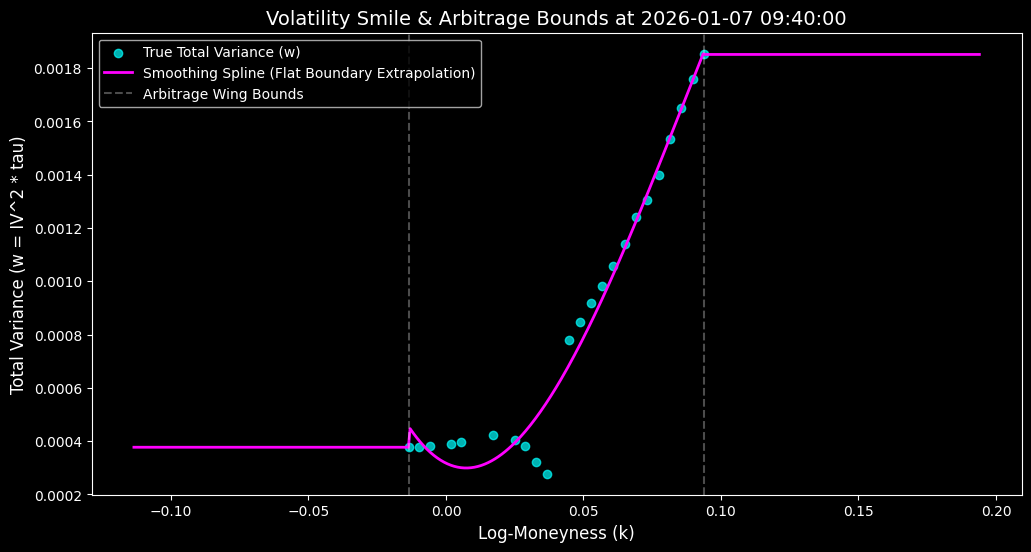

In [4]:
# Load and process just enough data to get the splines
df = pd.read_csv('../data/raw/dataset.csv')
df_long = transform_and_engineer_memory(df)

# Isolate a single timestamp to visualize the smile
sample_time = df_long['datetime'].unique()[5]
sample_df = df_long[df_long['datetime'] == sample_time].copy()

# Fit the spline manually for plotting
from scipy.interpolate import UnivariateSpline
sample_df = sample_df.dropna(subset=['w'])
grouped = sample_df.groupby('log_moneyness', as_index=False)['w'].mean()

x = grouped['log_moneyness'].values
y = grouped['w'].values
spline = UnivariateSpline(x, y, k=3, s=0.0001)

# Generate smooth points for the line
x_smooth = np.linspace(x.min() - 0.1, x.max() + 0.1, 500)
y_spline = [spline(val) if x.min() <= val <= x.max() else (y[0] if val < x.min() else y[-1]) for val in x_smooth]

# Plot
plt.figure(figsize=(12, 6))
plt.scatter(x, y, color='cyan', label='True Total Variance (w)', alpha=0.7)
plt.plot(x_smooth, y_spline, color='magenta', linewidth=2, label='Smoothing Spline (Flat Boundary Extrapolation)')
plt.axvline(x.min(), color='white', linestyle='--', alpha=0.3, label='Arbitrage Wing Bounds')
plt.axvline(x.max(), color='white', linestyle='--', alpha=0.3)

plt.title(f"Volatility Smile & Arbitrage Bounds at {sample_time}", fontsize=14)
plt.xlabel("Log-Moneyness (k)", fontsize=12)
plt.ylabel("Total Variance (w = IV^2 * tau)", fontsize=12)
plt.legend()

# Save this to your assets folder!
plt.savefig('../assets/spline_flat_wings.png', bbox_inches='tight', dpi=300)
plt.show()